# 06 — Transformers

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

The transformer ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)) replaced recurrence by a single operation: **self-attention**, a
learned, data-dependent weighted average over a sequence. This notebook builds it from the equations up,
in about a hundred lines of code, and then trains a miniature **BERT** on Shakespeare: first to fill in
masked characters, then to write, one character at a time.

### Table of Contents

1. **Self-attention** — queries, keys, values, and the kernel view
2. **Why $1/\sqrt{d_a}$** — keeping the softmax awake
3. **Multi-head attention** — several low-rank views of the same sequence
4. **Positional encoding** — attention is a *set* operation; order has to be injected
5. **The transformer block** — residual stream, LayerNorm, token-wise MLP
6. **Masked language modeling** — a character-level BERT on Tiny Shakespeare, and next-character generation
7. **Modern self-attention** — what changes at $10^{11}$ parameters

In [1]:
%matplotlib inline
import pathlib, urllib.request
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


## 1. Self-attention

**Idea.** Each token reads a weighted average of information from other tokens.

Take $n$ input vectors $x_i \in \mathbb{R}^{d_m}$, stacked as rows of $X \in \mathbb{R}^{n \times d_m}$.
Three learned projections turn each token into a **query**, a **key** and a **value**,

$$
Q_i = W_Q^\top x_i, \qquad K_j = W_K^\top x_j, \qquad V_j = W_V^\top x_j,
$$

with $W_Q, W_K \in \mathbb{R}^{d_m \times d_a}$ and $W_V \in \mathbb{R}^{d_m \times d_v}$; in matrix form
$Q = X W_Q$, $K = X W_K$, $V = X W_V$. Token $i$ *asks a question* with $Q_i$, token $j$ *advertises what
it is* with $K_j$, and the match is measured by an inner product. The attention weight from $i$ to $j$ is

$$
\alpha_{ij} = \operatorname{softmax}_j\!\left(\frac{\langle Q_i, K_j\rangle}{\sqrt{d_a}}\right)
            = \frac{\exp\!\big(\langle Q_i, K_j\rangle / \sqrt{d_a}\big)}
                   {\sum_{k} \exp\!\big(\langle Q_i, K_k\rangle / \sqrt{d_a}\big)},
\qquad\qquad
\operatorname{Attn}(x_i, X) = \sum_j \alpha_{ij} V_j .
$$

Three observations set the tone for everything that follows.

**(i) It is an average.** Each row $\alpha_i$ lives in the probability simplex, so the output is a *convex
combination* of the values. Attention interpolates between tokens; it never leaves the convex hull of $V$.

**(ii) It is a kernel method.** Writing $\kappa(x_i, x_j) = \exp\big(\langle Q_i, K_j\rangle/\sqrt{d_a}\big)$,

$$
\operatorname{Attn}(x_i, X) = \frac{\sum_j \kappa(x_i, x_j)\, V_j}{\sum_k \kappa(x_i, x_k)},
$$

which is exactly the classical **Nadaraya–Watson** kernel regression estimator with a kernel that is *learned*.

**(iii) It costs $\mathcal{O}(n^2)$.** Every pair $(i,j)$ is scored, so $n^2 d_a$ operations and — unless one
is careful — an $n \times n$ matrix in memory. This single quadratic is the reason for much of modern
architecture research (§7).

**Code and plot.** Compute attention in a few lines, check the row sums, and plot the attention matrix.

In [2]:
n, d_model, d_attn, d_value = 15, 5, 4, 16          # tokens, d_m, d_a, d_v
X = torch.randn(n, d_model)
Wq, Wk, Wv = torch.randn(d_model, d_attn), torch.randn(d_model, d_attn), torch.randn(d_model, d_value)

def self_attention(X, Wq, Wk, Wv):
    Q, K, V = X @ Wq, X @ Wk, X @ Wv                # [n,da], [n,da], [n,dv]
    scores = Q @ K.T / Q.shape[-1] ** 0.5           # einsum('il,jl->ij', Q, K)   [n,n]
    alpha = scores.softmax(dim=1)                   # row-stochastic              [n,n]
    return alpha @ V, alpha                         # einsum('ij,jd->id', ...)    [n,dv]

Y, alpha = self_attention(X, Wq, Wk, Wv)
print("Y:", tuple(Y.shape), " alpha:", tuple(alpha.shape), " row sums:", alpha.sum(1)[:4].numpy().round(3))

Y: (15, 16)  alpha: (15, 15)  row sums: [1. 1. 1. 1.]


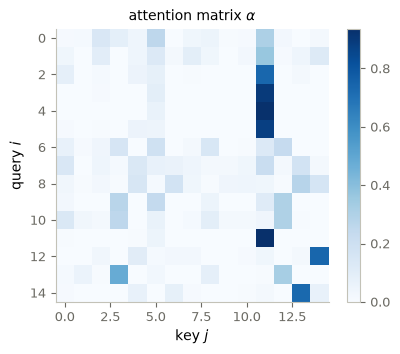

In [3]:
fig, ax = P.panels(figsize=(4.4, 3.6))
P.heatmap(ax, alpha, vmin=0, xlabel="key $j$", ylabel="query $i$",
        title=r"attention matrix $\alpha$")
plt.show()

## 2. Why the $1/\sqrt{d_a}$

**Idea.** Control the size of inner products before applying softmax.

Suppose the entries of $Q_i$ and $K_j$ are independent with mean $0$ and variance $1$. Then

$$
\langle Q_i, K_j \rangle = \sum_{\ell=1}^{d_a} Q_{i\ell} K_{j\ell}
\quad\Longrightarrow\quad
\mathbb{E}\big[\langle Q_i, K_j\rangle\big] = 0, \qquad
\operatorname{Var}\big[\langle Q_i, K_j\rangle\big] = d_a .
$$

The logits therefore have typical size $\sqrt{d_a}$, which *grows with the model*. A softmax fed logits of
size $\sqrt{d_a} \gg 1$ collapses onto a single entry, and its Jacobian

$$
\frac{\partial \alpha_i}{\partial s_i} = \operatorname{diag}(\alpha_i) - \alpha_i \alpha_i^\top
$$

vanishes as $\alpha_i \to$ one-hot: **no gradient reaches $W_Q$ and $W_K$**. Dividing by $\sqrt{d_a}$
normalizes the variance back to $1$, so the logits stay $\mathcal{O}(1)$ at every width.

We can see the collapse directly by measuring the entropy $H(\alpha_i) = -\sum_j \alpha_{ij}\log \alpha_{ij}$
of the attention rows, whose maximum $\log n$ corresponds to uniform attention.

**Code and plot.** Compare the entropy of scaled and unscaled attention as the width increases.

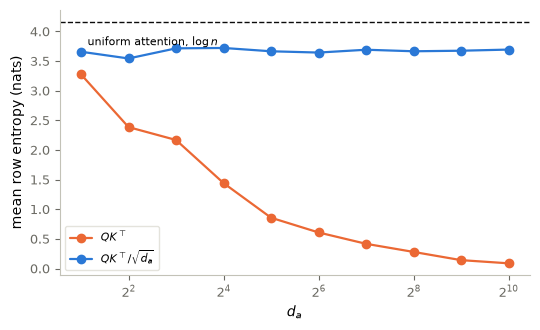

In [4]:
n, ds = 64, [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
entropy = {True: [], False: []}
for d in ds:
    Q, K = torch.randn(n, d), torch.randn(n, d)
    for scaled in (True, False):
        A = (Q @ K.T / (d ** 0.5 if scaled else 1.0)).softmax(dim=1)
        entropy[scaled].append(-(A * A.clamp_min(1e-12).log()).sum(1).mean().item())

fig, ax = P.panels(figsize=(5.5, 3.4))
P.curves(ax, ds, {r"$QK^\top$": (entropy[False], {"color": P.ORANGE, "marker": "o", "base": 2}),
                r"$QK^\top/\sqrt{d_a}$": (entropy[True], {"color": P.BLUE, "marker": "o", "base": 2})},
       log="x", xlabel="$d_a$", ylabel="mean row entropy (nats)")
ax.axhline(np.log(n), ls="--", color=P.INK, lw=1)
ax.text(2.2, np.log(n) - 0.4, "uniform attention, $\\log n$", fontsize=8)
plt.show()

## 3. Multi-head attention

**Idea.** Let different heads learn different comparisons between tokens.

One attention map can only express one notion of relevance. **Multi-head attention** runs $h$ independent
copies in parallel, each in a subspace of width $d_m/h$, and concatenates the results:

$$
\operatorname{MHA}(X) = \big[\,H_1 \;\|\; \cdots \;\|\; H_h\,\big]\, W_O,
\qquad
H_m = \operatorname{Attn}\!\big(X W_Q^{(m)},\, X W_K^{(m)},\, X W_V^{(m)}\big),
$$

with $W_O \in \mathbb{R}^{d_m \times d_m}$. Because $d_a = d_v = d_m/h$, the leading-order projection and attention arithmetic is comparable to a *single*
head of full width. Storing a separate attention map for each head still uses more memory. What they buy is **rank**: each $W_Q^{(m)} W_K^{(m)\top}$ is a
bilinear form of rank at most $d_m/h$, so the model gets $h$ different low-rank comparisons instead of one.
Empirically the heads specialize.

In code, the three projections are fused into one `Linear` and the head axis is just a reshape.

**Code and plot.** Implement multiple heads by reshaping the projected queries, keys, and values.

In [5]:
def attention(Q, K, V):                                  # Q,K,V: [..., n, d]
    A = (Q @ K.transpose(-2, -1) / K.shape[-1] ** 0.5).softmax(dim=-1)
    return A @ V, A

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.h = n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)       # W_Q, W_K, W_V for all heads at once
        self.out = nn.Linear(d_model, d_model)           # W_O

    def forward(self, X):                                # X: [B, n, d_model]
        B, n, d = X.shape
        Q, K, V = self.qkv(X).view(B, n, 3, self.h, d // self.h).permute(2, 0, 3, 1, 4)
        Y, A = attention(Q, K, V)                        # Y: [B, h, n, d/h],  A: [B, h, n, n]
        return self.out(Y.transpose(1, 2).reshape(B, n, d)), A

## 4. Positional encoding

**Idea.** Supply positions so attention can use the order of a sequence.

Here is the catch. Let $P$ be an $n \times n$ permutation matrix. Then $Q \mapsto PQ$, $K \mapsto PK$,
$V \mapsto PV$, the scores become $P S P^\top$, and since the softmax acts row-wise,

$$
\operatorname{Attn}(PX) = P\,\alpha\, P^\top \cdot P V = P\, \alpha V = P \operatorname{Attn}(X).
$$

Self-attention is **permutation-equivariant**, and so is everything else in the block (LayerNorm and the MLP
act on each token separately). Without positional information, the block treats its inputs as an unordered collection: permuting them simply permutes its outputs. It cannot represent word-order relationships through attention alone.

**Code and plot.** Permute the inputs and verify that the outputs permute with them.

In [6]:
X, perm = torch.randn(1, 6, 8), torch.randperm(6)
mha = MultiHeadAttention(d_model=8, n_heads=2)
with torch.no_grad():
    err = (mha(X)[0][:, perm] - mha(X[:, perm])[0]).abs().max()
print(f"|Attn(PX) - P Attn(X)| = {err:.2e}")

|Attn(PX) - P Attn(X)| = 5.96e-08


Order must therefore be *injected into the inputs*. The original paper adds a fixed **sinusoidal positional
encoding** to the token embeddings, $h_p^{(0)} = E_{t_p} + PE_p$, with

$$
PE_{p,\,2k} = \sin\!\left(\omega_k\, p\right), \qquad
PE_{p,\,2k+1} = \cos\!\left(\omega_k\, p\right), \qquad
\omega_k = 10000^{-2k/d_m}.
$$

Some remarks on why this particular choice:

- **It is a clock at many speeds.** Dimensions $(2k, 2k+1)$ trace the unit circle at angular frequency
  $\omega_k$. The wavelengths $2\pi/\omega_k$ form a geometric progression from $2\pi$ to $2\pi \cdot 10^4$,
  so the fast dimensions resolve immediate neighbors while the slow ones carry coarse global position —
  much like the bits of a binary counter, but smooth and bounded in $[-1,1]$.

- **Relative position is a linear map.** From the angle-addition formulas, for every offset $\Delta$

  $$
  \begin{pmatrix} \sin \omega_k (p+\Delta) \\ \cos \omega_k (p+\Delta) \end{pmatrix}
  = \underbrace{\begin{pmatrix} \cos \omega_k \Delta & \sin \omega_k \Delta \\
                               -\sin \omega_k \Delta & \cos \omega_k \Delta \end{pmatrix}}_{\text{rotation }R(\omega_k \Delta)}
    \begin{pmatrix} \sin \omega_k p \\ \cos \omega_k p \end{pmatrix}
  \qquad\Longrightarrow\qquad
  PE_{p+\Delta} = M_\Delta\, PE_p ,
  $$

  where the block-diagonal $M_\Delta$ does **not** depend on $p$. So a *linear* layer inside $W_Q$ can
  implement "attend $\Delta$ positions back", uniformly along the sequence. This is the property the
  encoding was designed for.

- **The score already knows about distance.** Since $\sin a \sin b + \cos a \cos b = \cos(a-b)$,

  $$
  \langle PE_p, PE_q \rangle = \sum_k \cos\!\big(\omega_k (p-q)\big),
  $$

  a function of $p-q$ alone, maximal at $0$ but oscillatory, rather than monotonically decreasing with $|p-q|$: a built-in "nearby tokens are
  relevant" prior, before any training.

- **It is fixed, not learned**, so it is defined at positions never seen during training — the original
  motivation for extrapolating to longer sequences. In practice sinusoidal encodings extrapolate poorly,
  and modern models use learned embeddings or, most often, **RoPE** ([Su et al., 2021](https://arxiv.org/abs/2104.09864)), which applies the
  same rotation $R(\omega_k \Delta)$ directly to $Q$ and $K$ so that the positional part of the interaction depends on the relative offset $p-q$. The scores also depend on token content.

**Code and plot.** Plot the positional encoding and its similarity across offsets.

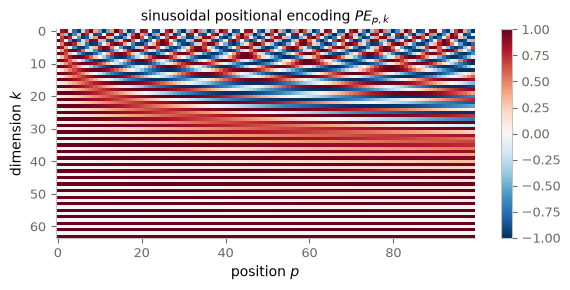

In [7]:
def positional_encoding(n, d):
    pos, i = torch.arange(n)[:, None], torch.arange(0, d, 2)[None, :]
    angle = pos / 10000 ** (i / d)                       # [n, d/2], omega_k * p
    PE = torch.zeros(n, d)
    PE[:, 0::2], PE[:, 1::2] = torch.sin(angle), torch.cos(angle)
    return PE

PE = positional_encoding(100, 64)

fig, ax = P.panels(figsize=(6, 3.0))
P.heatmap(ax, PE.T, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto",
        xlabel="position $p$", ylabel="dimension $k$",
        title="sinusoidal positional encoding $PE_{p,k}$")
plt.show()

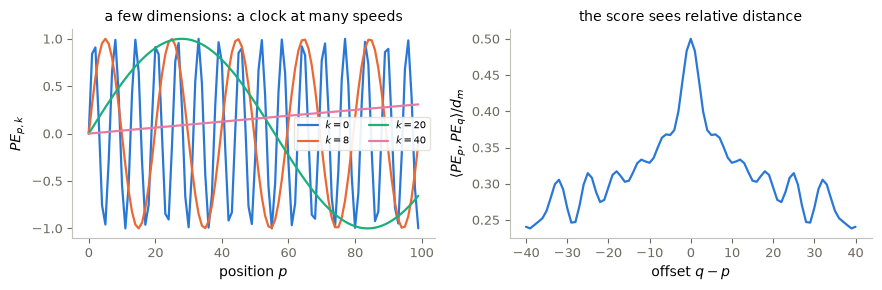

In [8]:
fig, axes = P.panels(2, size=(4.5, 3.0))
P.curves(axes[0], None, {f"$k={k}$": (PE[:, k], c)
                       for k, c in zip([0, 8, 20, 40], [P.BLUE, P.ORANGE, P.AQUA, P.MAGENTA])},
       xlabel="position $p$", ylabel="$PE_{p,k}$",
       title="a few dimensions: a clock at many speeds", legend={"fontsize": 7, "ncol": 2})
offsets = np.arange(-40, 41)
P.curves(axes[1], offsets, [(PE[50] @ PE[50 + o]).item() / PE.shape[1] for o in offsets],
       xlabel="offset $q - p$", ylabel=r"$\langle PE_p, PE_q \rangle / d_m$",
       title="the score sees relative distance")
plt.show()

## 5. The transformer block

**Idea.** Alternate attention across tokens with an MLP on each token.

A block alternates **mixing across tokens** (attention) with **mixing across features** (a token-wise MLP),
each wrapped in a residual connection around a LayerNorm:

$$
\tilde h = h + \operatorname{MHA}\big(\operatorname{LN}(h)\big),
\qquad
h^{+} = \tilde h + \operatorname{MLP}\big(\operatorname{LN}(\tilde h)\big),
\qquad
\operatorname{MLP}(z) = W_2\, \sigma(W_1 z + b_1) + b_2 ,
$$

with $W_1 \in \mathbb{R}^{4 d_m \times d_m}$ (the usual expansion factor) and $\sigma$ a GELU. Note:

- The **residual stream** $h \mapsto h + f(h)$ is exactly the ResNet structure of notebook 04, i.e. one
  explicit Euler step of $\dot h = f_\theta(h)$. A deep transformer is a discretized flow on a *cloud of
  $n$ interacting particles*, where attention supplies the interaction between them. This is the starting
  point for the mean-field analyses of transformers ([Geshkovski et al., 2023](https://arxiv.org/abs/2312.10794)).
- Only attention moves information **between** positions; the MLP is applied independently at each token
  and holds most of the parameters ($8 d_m^2$ against $4 d_m^2$ for attention).
- Putting the LayerNorm *inside* the branch ("pre-LN") keeps the residual path an exact identity and can
  improve gradient behavior and reduce the need for learning-rate warm-up ([Xiong et al., 2020](https://arxiv.org/abs/2002.04745)). The 2017 architecture used "post-LN" and a warm-up schedule.

**Code and plot.** Build the residual block and a small encoder from the components above.

In [9]:
class Block(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(),
                                 nn.Linear(4 * d_model, d_model))

    def forward(self, X):
        Y, A = self.attn(self.ln1(X))
        X = X + Y                                        # attention  : mixes tokens
        return X + self.mlp(self.ln2(X)), A              # MLP        : mixes features

class TinyBERT(nn.Module):
    def __init__(self, vocab, n, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.emb = nn.Embedding(vocab, d_model)
        self.register_buffer("pe", positional_encoding(n, d_model))
        self.blocks = nn.ModuleList([Block(d_model, n_heads) for _ in range(n_layers)])
        self.ln, self.head = nn.LayerNorm(d_model), nn.Linear(d_model, vocab)

    def forward(self, tokens):                           # tokens: [B, n] of token ids
        X, maps = self.emb(tokens) + self.pe[:tokens.shape[1]], []
        for block in self.blocks:
            X, A = block(X)
            maps.append(A)
        return self.head(self.ln(X)), maps               # logits: [B, n, vocab]

## 6. BERT-style masked language modeling

**Idea.** Learn to predict missing characters from the surrounding text.

**BERT** ([Devlin et al., 2019](https://arxiv.org/abs/1810.04805)) trains the encoder above as a *denoiser*. Corrupt a piece of text
$t = (t_1,\dots,t_n)$ by replacing the tokens at a random subset $M \subset \{1,\dots,n\}$ with a special
`[MASK]` symbol, call the result $\tilde t$, and minimize

$$
\mathcal{L}(\theta) = -\,\mathbb{E}_{t,\,M} \sum_{p \in M} \log p_\theta\big(t_p \mid \tilde t\big),
\qquad
p_\theta(\,\cdot \mid \tilde t) = \operatorname{softmax}\big(W\, h_p^{(L)} + b\big).
$$

Because there is no causal mask, $h_p^{(L)}$ sees the whole window — *both* sides of the gap. That is the
difference from a GPT-style decoder, which masks the upper triangle of $\alpha$ and predicts $t_{p+1}$ from
$t_{\le p}$. BERT masks $15\%$ of tokens; of those, $80\%$ become `[MASK]`, $10\%$ a random word and $10\%$
are left alone, so the model cannot simply ignore unmasked positions. We keep plain `[MASK]`.

### Tiny Shakespeare

The corpus is **Tiny Shakespeare** ([Karpathy, 2015](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)): about $1.1$M characters of
Shakespeare's plays in a single 1 MB text file. We tokenize by **characters**, so the vocabulary is the $65$
characters that occur plus `[MASK]`, and a training example is a random window of $n = 64$ consecutive
characters. The first $10^6$ characters are for training; the last $\approx 10^5$ are held out.

**Code and plot.** Download the text, look at a few windows, train, and inspect the model's predictions.

In [10]:
# Tiny Shakespeare: 1.1M characters of the plays, downloaded once into ./data
DATA = pathlib.Path("data"); DATA.mkdir(exist_ok=True)
path = DATA / "tinyshakespeare.txt"
if not path.exists():
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", path)
text = path.read_text()

VOCAB = ["[MASK]"] + sorted(set(text))                      # one token per character
stoi, MASK, N = {c: i for i, c in enumerate(VOCAB)}, 0, 64
data = torch.tensor([stoi[c] for c in text])
train, test = data[:1_000_000], data[1_000_000:]
show = lambda ids: "".join("_" if i == MASK else VOCAB[i] for i in ids)

def windows(src, B):                                         # B random windows of N characters
    i = torch.randint(0, len(src) - N, (B, 1))
    return src[i + torch.arange(N)]

print(f"{len(text):,} characters, vocabulary {len(VOCAB)}, window n = {N}")
for w in windows(train, 3):
    print("-" * 64 + "\n" + show(w))

1,115,394 characters, vocabulary 66, window n = 64
----------------------------------------------------------------
must what force will have us do.
Set on towards London, cousin, 
----------------------------------------------------------------
know each other's faces,
But for our hearts, he knows no more of
----------------------------------------------------------------
ert thou regent of the world,
It were a shame to let this land b


Masking is three lines: draw a Bernoulli$(0.15)$ mask, hide those tokens, and set every *unmasked* target to
`-100` so that `cross_entropy` ignores it — the loss lives only on the holes. We add one line that is *not*
in BERT: the **last** character of every window is always hidden as well. A hole in the middle of a window
sees text on both sides, but generation (below) asks the opposite question — the next character, with
nothing to its right — and without this line the model would meet it only in the few windows whose last
character happens to be drawn.

In [11]:
def corrupt(x):
    tokens, target = x.clone(), x.clone()
    m = torch.rand(x.shape) < 0.15
    m[:, -1] = True                                          # always hide the last character too
    tokens[m], target[~m] = MASK, -100                       # hide the token, score only the holes
    return tokens, target

model = TinyBERT(len(VOCAB), N)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
print("parameters:", sum(p.numel() for p in model.parameters()))

losses, accs = [], []
for it in range(2001):
    tokens, target = corrupt(windows(train, 64))
    logits, _ = model(tokens)
    L = nn.functional.cross_entropy(logits.reshape(-1, len(VOCAB)), target.reshape(-1))
    opt.zero_grad(); L.backward(); opt.step()
    losses.append(L.item())
    if it % 100 == 0:                                        # held-out text, never trained on
        with torch.no_grad():
            tk, tg = corrupt(windows(test, 512))
            hole = tg != -100
            accs.append((model(tk)[0].argmax(-1)[hole] == tg[hole]).float().mean().item())
        if it % 500 == 0:
            print(f"iteration {it:4d}:  loss = {L.item():.3f},  test accuracy on masked characters = {accs[-1]:.1%}")

parameters: 108610


iteration    0:  loss = 4.380,  test accuracy on masked characters = 14.9%


iteration  500:  loss = 2.506,  test accuracy on masked characters = 30.5%


iteration 1000:  loss = 1.756,  test accuracy on masked characters = 45.5%


iteration 1500:  loss = 1.540,  test accuracy on masked characters = 49.4%


iteration 2000:  loss = 1.523,  test accuracy on masked characters = 51.2%


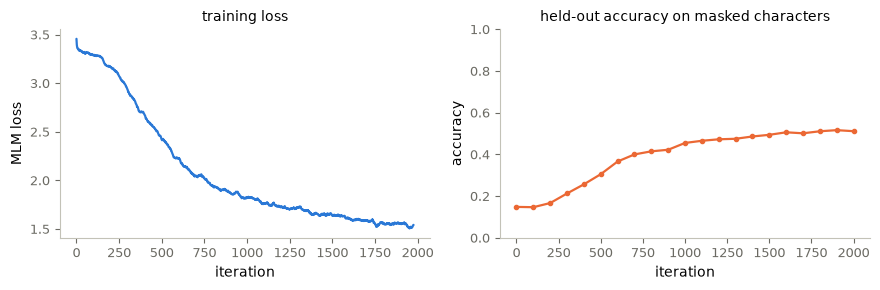

In [12]:
fig, axes = P.panels(2, size=(4.5, 3.0))
P.curves(axes[0], None, P.smooth(losses, 25), xlabel="iteration", ylabel="MLM loss",
       title="training loss")
P.curves(axes[1], np.arange(len(accs)) * 100, (accs, {"color": P.ORANGE, "marker": "o", "ms": 3}),
       xlabel="iteration", ylabel="accuracy", ylim=(0, 1),
       title="held-out accuracy on masked characters")
plt.show()

### Filling in the blanks

Hide a single character of held-out text, the `e` in *see the like*, and ask the model for it. The shaded
slot holds its most likely character; the bars show the whole distribution, the hidden character in orange.

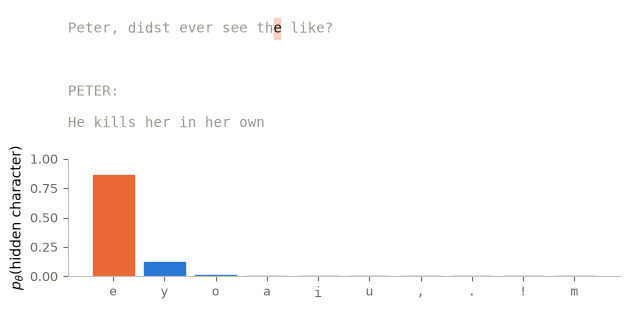

In [13]:
i = text.index("Peter, didst ever see the like?", 1_000_000)  # a line of held-out text
x, hole = data[i : i + N], len("Peter, didst ever see th")     # a window, and the e of "the"
tokens = x.clone(); tokens[hole] = MASK
with torch.no_grad():
    logits, _ = model(tokens[None])
P.fill_in(show(x), hole, logits[0, hole].softmax(-1), VOCAB)
plt.show()

### Writing, one character at a time

Any distribution over strings factorizes by the chain rule,

$$
p(t_1, \dots, t_T) = \prod_{k=1}^{T} p\big(t_k \mid t_1, \dots, t_{k-1}\big),
$$

so a model of the *next* character is a generative model: sample $t_k$, append it, and repeat. Our BERT
supplies that conditional — feed it the last $n-1$ characters followed by a `[MASK]` and read the
distribution at the hole,

$$
p_\theta\big(t_k \mid t_{k-n+1}, \dots, t_{k-1}\big)
= \operatorname{softmax}\big(W h_n^{(L)} + b\big)
\quad\text{on the input}\quad \big(t_{k-n+1}, \dots, t_{k-1}, \texttt{[MASK]}\big).
$$

The window slides along, so the model never sees more than the last $63$ characters. We sample at
temperature $\tau = 0.8$, i.e. from $\operatorname{softmax}(\text{logits}/\tau)$, which sharpens the
distribution slightly.

This is exactly the task a GPT-style decoder is trained on — at *every* position of every window at once,
thanks to the causal mask — whereas our BERT practises it once per window. That is why generation belongs
to decoders, and why a two-minute BERT writes Shakespeare only in *texture*.

**Code and plot.** Sample a passage, then watch the first steps of the chain rule one character at a time.

In [14]:
def generate(prompt, steps, tau=0.8):
    ids, probs = [stoi[c] for c in prompt], []
    for _ in range(steps):
        x = torch.tensor(ids[-(N - 1):] + [MASK])               # the last n-1 characters, then a hole
        with torch.no_grad():
            p = (model(x[None])[0][0, -1] / tau).softmax(-1)
        ids.append(torch.multinomial(p, 1).item()); probs.append(p)
    return ids[len(prompt):], torch.stack(probs)

torch.manual_seed(0)

prompt = "JULIET:\nO Romeo, Romeo! wherefore art thou"
sampled, probs = generate(prompt, 60)
P.animate_generation(prompt, sampled, probs, VOCAB)

## 7. Modern self-attention

**Idea.** Larger models retain the core operations but need more efficient implementations.

The core operations in §1–§5 also appear in larger models, alongside additional architectural and implementation choices. The 2017 base model had $65$M parameters and was
trained in twelve hours on eight GPUs. BERT-base has $110$M, GPT-2 has $1.5$B, and [GPT-3](https://arxiv.org/abs/2005.14165) has $175$B spread
over $96$ layers with $d_m = 12288$ and $96$ heads — at $2$ bytes per parameter in `float16` the *weights
alone* occupy about $350$ GB, so the model cannot be held on one $80$ GB accelerator and requires multiple accelerators just to store those weights; [Llama 3.1 405B](https://arxiv.org/abs/2407.21783) needs roughly $810$ GB at the same precision. Our `TinyBERT` has about $10^5$ parameters,
some six orders of magnitude less, and is the same six equations.

Two costs then dominate engineering. First, **memory at inference**: a decoder caches $K$ and $V$ for
every past token, $2 \cdot L \cdot d_m$ values per token, which for GPT-3 is $\approx 4.7$ MB per token, or
about $10$ GB for a full $2048$-token context — *per sequence*. This is why grouped-query and multi-query
attention, which share keys and values across heads, are now standard. Second, **the $\mathcal{O}(n^2)$
itself**: context windows have gone from $2048$ tokens to $10^5$–$10^6$, where a single head's attention
matrix would have $10^{12}$ entries. **FlashAttention** ([Dao et al., 2022](https://arxiv.org/abs/2205.14135)) does not reduce the arithmetic
but tiles the computation so the $n \times n$ matrix is never written to memory, which is what made long
contexts practical; sliding-window and sparse patterns, linear-attention and state-space models (Mamba), and
mixture-of-experts layers for growing parameters without growing compute all attack the same two walls.

The mathematically interesting point is that scale did not require a new mechanism. A learned, asymmetric
kernel smoother, stacked in a residual stream — that is still all it is.

## Key takeaways

- Self-attention forms data-dependent convex combinations of value vectors.
- Scaling keeps attention logits controlled; multiple heads learn different comparisons.
- Positional information lets the model use word order.
- Masked-token prediction trains the encoder to combine information from both sides of a hole.
- A `[MASK]` after the context turns it into a next-token model, and the chain rule turns that into a generator.

## Exercises

1. **Scaling.** Remove the factor $1/\sqrt{d_a}$ and compare attention entropy as the width grows.
2. **Order.** Remove the positional encoding from `TinyBERT`, retrain, and generate. Which features of the text survive?
3. **Heads.** Train with one head and four heads at the same model width. Compare held-out accuracy and the attention maps.
4. **Next character.** Delete the line that always hides the last character, retrain, and compare the generated text.

## References

1. A. Vaswani et al., *Attention Is All You Need*, NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
2. J. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*, NAACL 2019. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
3. A. Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks*, 2015. [karpathy.github.io](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) — the source of Tiny Shakespeare.
4. A. Rush, *The Annotated Transformer*, 2018. [nlp.seas.harvard.edu](https://nlp.seas.harvard.edu/2018/04/03/attention.html) — the paper reimplemented line by line.
5. Y.-H. Tsai et al., *Transformer Dissection: A Unified Understanding of Transformer's Attention via the Lens of Kernel*, EMNLP 2019. [arXiv:1908.11775](https://arxiv.org/abs/1908.11775)
6. R. Xiong et al., *On Layer Normalization in the Transformer Architecture*, ICML 2020. [arXiv:2002.04745](https://arxiv.org/abs/2002.04745)
7. J. Su et al., *RoFormer: Enhanced Transformer with Rotary Position Embedding*, 2021. [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
8. T. Dao et al., *FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness*, NeurIPS 2022. [arXiv:2205.14135](https://arxiv.org/abs/2205.14135)
9. N. Elhage et al., *A Mathematical Framework for Transformer Circuits*, Anthropic, 2021. [transformer-circuits.pub](https://transformer-circuits.pub/2021/framework/index.html)
10. B. Geshkovski, C. Letrouit, Y. Polyanskiy, P. Rigollet, *A Mathematical Perspective on Transformers*, 2023. [arXiv:2312.10794](https://arxiv.org/abs/2312.10794) — attention as an interacting particle system.
11. A. Karpathy, *nanoGPT*. [github.com/karpathy/nanoGPT](https://github.com/karpathy/nanoGPT) — a decoder-only counterpart to §6, trained on the same Tiny Shakespeare.